# **A Comparative Study of Machine Learning Algorithms for Stock Market Prediction Using Yahoo Finance Data**

In [1]:
!pip install yfinance pandas --quiet

In [43]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt


## Define NIFTY 500 ticker and fetch data

In [44]:
ticker = "^CRSLDX"

# Fetch data: last 10 years daily data
nifty500 = yf.download(ticker, period="10y", interval="1d")

nifty500.head()

/tmp/ipykernel_164/4276465743.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty500 = yf.download(ticker, period="10y", interval="1d")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^CRSLDX,^CRSLDX,^CRSLDX,^CRSLDX,^CRSLDX
Date,,,,,
2016-03-14,6282.691895,6317.491653,6263.041530,6287.291498,5900300
2016-03-15,6222.641602,6282.691814,6214.691905,6282.691814,6132300
2016-03-16,6238.441895,6244.491691,6166.941990,6221.091820,6675900
2016-03-17,6255.741699,6307.791435,6233.891631,6287.041462,7647100
2016-03-18,6322.641602,6325.891597,6254.941983,6272.991764,7805000


In [45]:
# Save to CSV
nifty500.to_csv("NIFTY500_data.csv")
print("CSV saved successfully!")

CSV saved successfully!


## **Data Loading**

In [51]:
df = pd.read_csv('/content/NIFTY500_data.csv')
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,^CRSLDX,^CRSLDX,^CRSLDX,^CRSLDX,^CRSLDX
1,Date,NaN,NaN,NaN,NaN,NaN
2,2016-03-14,6282.69189453125,6317.491653240817,6263.041529868589,6287.291497829189,5900300
3,2016-03-15,6222.6416015625,6282.691814426415,6214.69190513586,6282.691814426415,6132300
4,2016-03-16,6238.44189453125,6244.491691168978,6166.941989667997,6221.09181996076,6675900


### Droping unwanted rows

In [52]:
df = df[~df['Price'].isin(['Ticker', 'Date'])]

df.reset_index(drop=True, inplace=True)

df.head()

,Price,Close,High,Low,Open,Volume
0,2016-03-14,6282.69189453125,6317.491653240817,6263.041529868589,6287.291497829189,5900300
1,2016-03-15,6222.6416015625,6282.691814426415,6214.69190513586,6282.691814426415,6132300
2,2016-03-16,6238.44189453125,6244.491691168978,6166.941989667997,6221.09181996076,6675900
3,2016-03-17,6255.74169921875,6307.791434841142,6233.891630555487,6287.0414623744055,7647100
4,2016-03-18,6322.6416015625,6325.891597295691,6254.941983411777,6272.9917644023335,7805000


In [53]:
if 'Price' in df.columns:
    df.rename(columns={'Price':'Date'}, inplace=True)


df['Date'] = pd.to_datetime(df['Date'])


df = df.sort_values('Date')
df.set_index('Date', inplace=True)


In [54]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2016-03-14,6282.69189453125,6317.491653240817,6263.041529868589,6287.291497829189,5900300
2016-03-15,6222.6416015625,6282.691814426415,6214.69190513586,6282.691814426415,6132300
2016-03-16,6238.44189453125,6244.491691168978,6166.941989667997,6221.09181996076,6675900
2016-03-17,6255.74169921875,6307.791434841142,6233.891630555487,6287.0414623744055,7647100
2016-03-18,6322.6416015625,6325.891597295691,6254.941983411777,6272.9917644023335,7805000


## EDA

In [55]:
import pandas as pd
null_counts = df.isnull().sum()
print("Null values in each column:\n", null_counts)

Null values in each column:
 Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [56]:
# Check for duplicates
duplicate_rows = df.duplicated()
print("Number of duplicated rows:", duplicate_rows.sum())


Number of duplicated rows: 0


In [59]:
# Convert all columns to numeric (ignore errors for non-numeric)
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check types
print(df.dtypes)

Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


In [60]:
# Resample yearly and compute average
df_yearly = df.resample('YE').mean()
df_yearly

,Close,High,Low,Open,Volume
Date,,,,,
2016-12-31,7015.750451,7048.894820,6980.712939,7020.305760,7.859141e+06
2017-12-31,8407.892239,8439.420438,8374.336838,8413.735566,1.055294e+07
2018-12-31,9268.278932,9315.629678,9220.344432,9279.023027,1.298564e+07
2019-12-31,9380.519551,9429.880851,9332.406999,9391.323458,1.532530e+07
2020-12-31,9160.688818,9231.574560,9087.195916,9171.811032,1.357276e+07
2021-12-31,13630.632903,13706.968851,13550.142949,13647.478604,9.645879e+06
2022-12-31,14782.759536,14865.926846,14692.108055,14793.199826,1.779861e+07
2023-12-31,16308.039983,16366.140027,16241.085112,16318.795081,4.787955e+07
2024-12-31,21888.960465,22000.533627,21768.741995,21913.065414,3.052297e+07


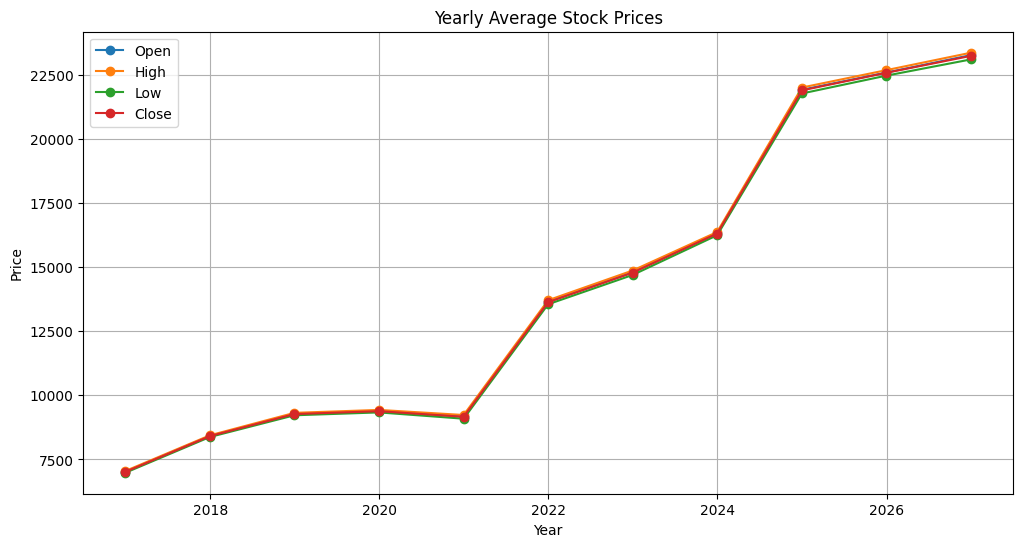

In [66]:
plt.figure(figsize=(12,6))
plt.plot(df_yearly.index, df_yearly['Open'], marker='o', label='Open')
plt.plot(df_yearly.index, df_yearly['High'], marker='o', label='High')
plt.plot(df_yearly.index, df_yearly['Low'], marker='o', label='Low')
plt.plot(df_yearly.index, df_yearly['Close'], marker='o', label='Close')
plt.title('Yearly Average Stock Prices')
plt.xlabel('Year')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

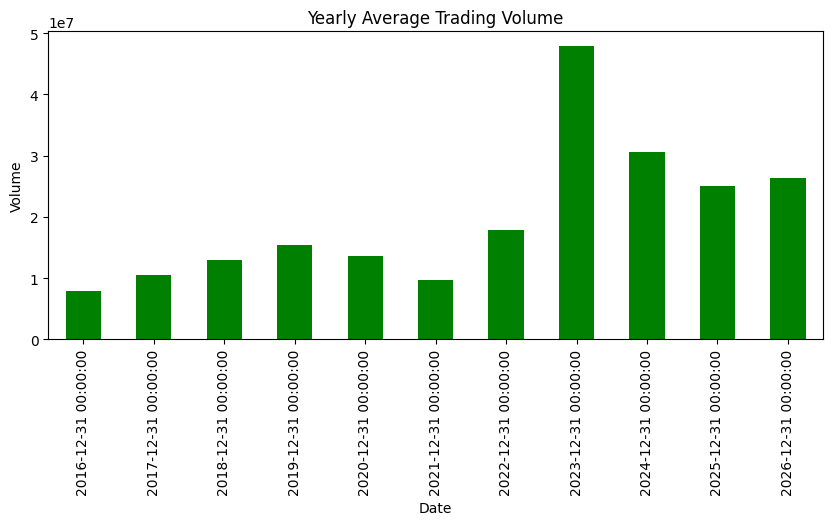

In [67]:
# Plot yearly average volume
plt.figure(figsize=(10,4))
df_yearly['Volume'].plot(kind='bar', color='green')
plt.title('Yearly Average Trading Volume')
plt.ylabel('Volume')
plt.show()

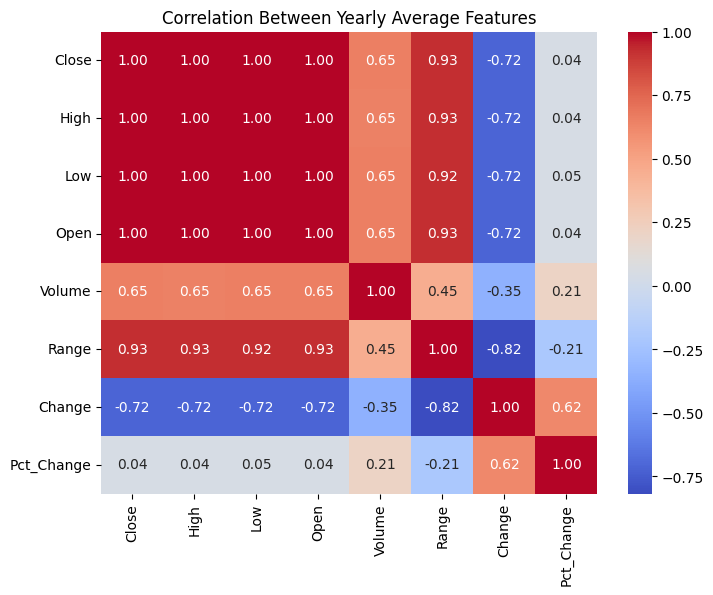

In [69]:
plt.figure(figsize=(8,6))
sns.heatmap(df_yearly.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Between Yearly Average Features')
plt.show()

/tmp/ipykernel_164/3667765817.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_yearly.index.year, y=df_yearly['Range'], palette='rocket')


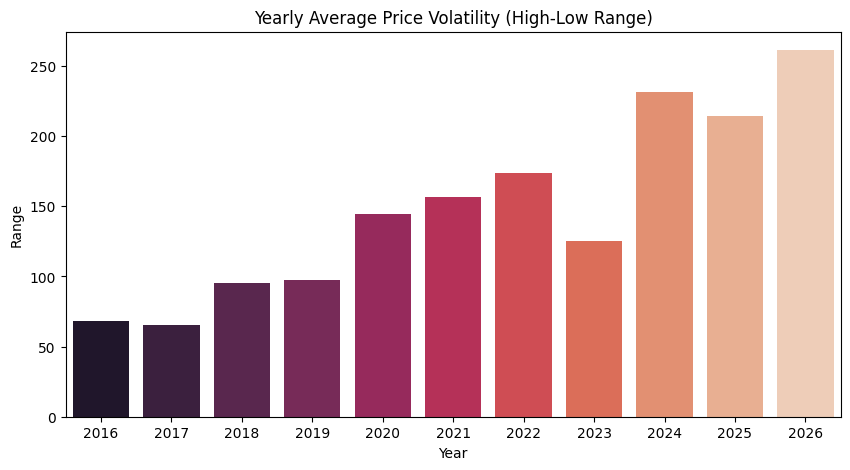

In [70]:
plt.figure(figsize=(10,5))
sns.barplot(x=df_yearly.index.year, y=df_yearly['Range'], palette='rocket')
plt.title('Yearly Average Price Volatility (High-Low Range)')
plt.xlabel('Year')
plt.ylabel('Range')
plt.show()

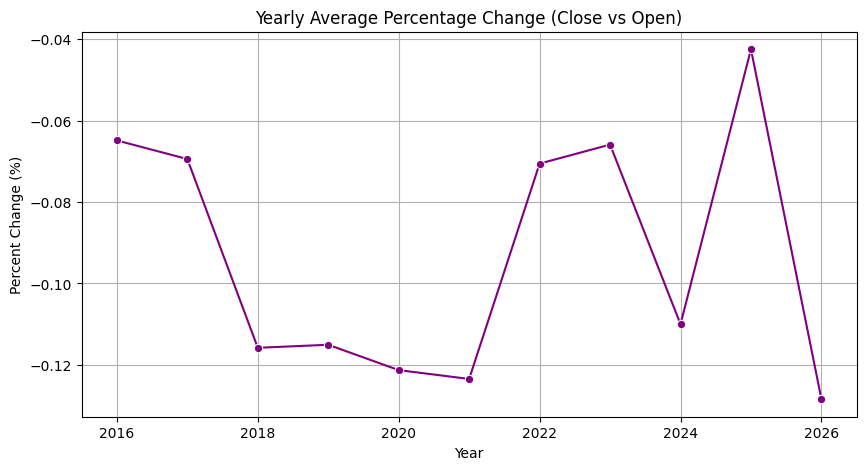

In [71]:
plt.figure(figsize=(10,5))
sns.lineplot(x=df_yearly.index.year, y=df_yearly['Pct_Change'], marker='o', color='purple')
plt.title('Yearly Average Percentage Change (Close vs Open)')
plt.xlabel('Year')
plt.ylabel('Percent Change (%)')
plt.grid(True)
plt.show()

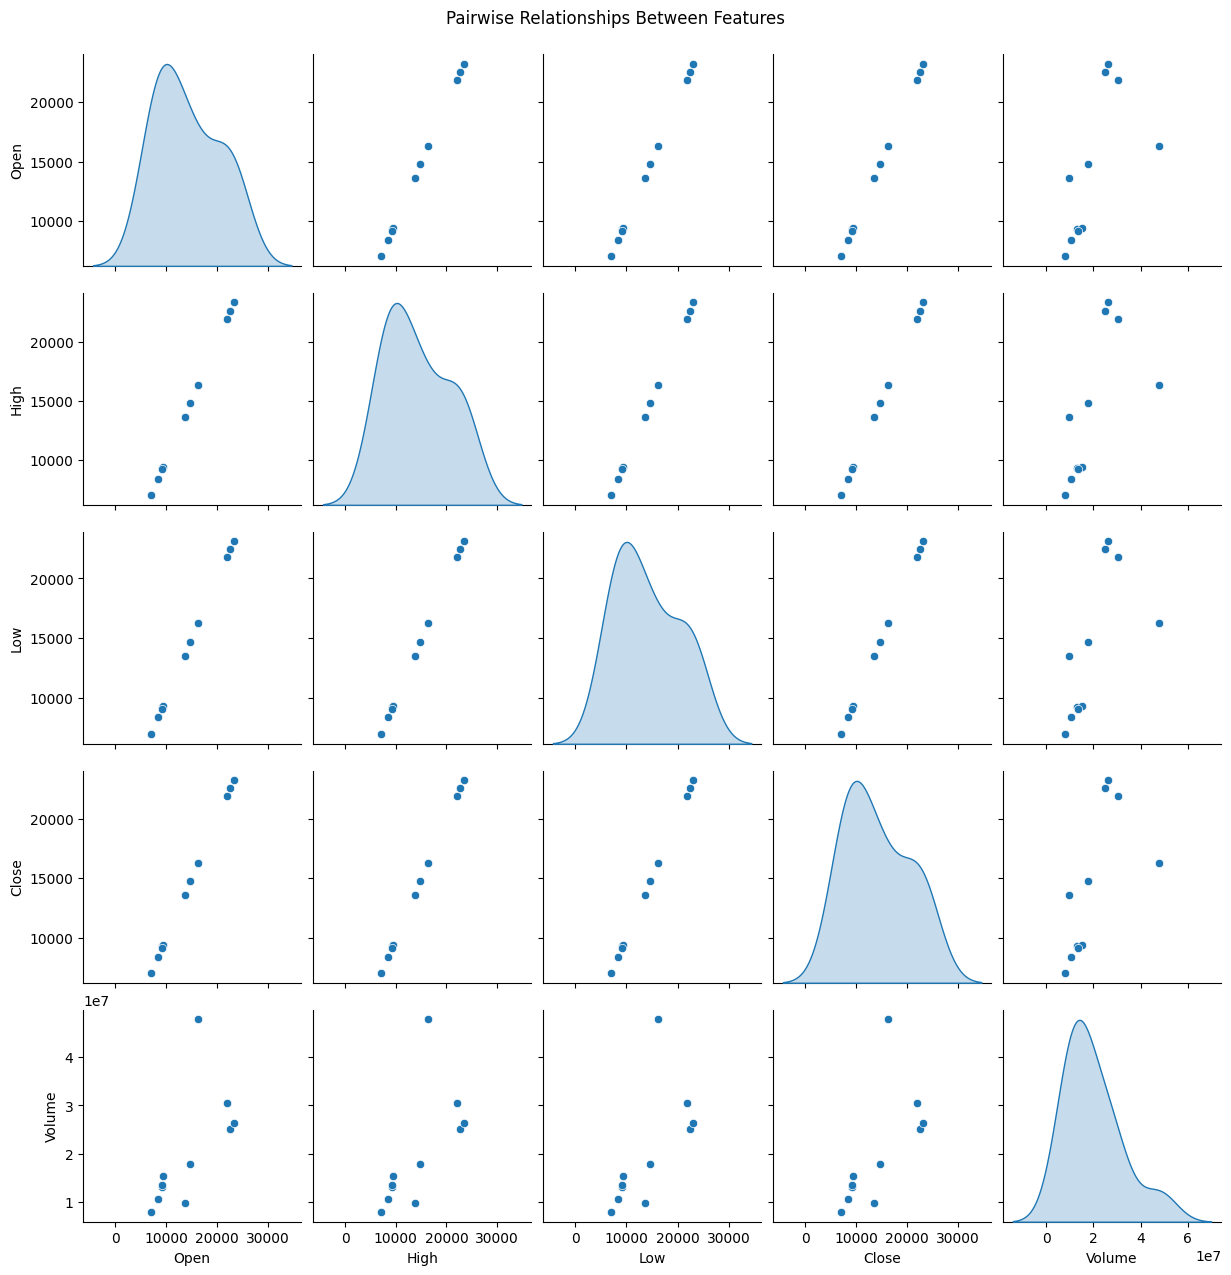

In [72]:
sns.pairplot(df_yearly[['Open','High','Low','Close','Volume']], kind='scatter', diag_kind='kde')
plt.suptitle('Pairwise Relationships Between Features', y=1.02)
plt.show()

## **LSTM with OHLCV**

## **LSTM with OHLCV + Moving Averages**

## **LSTM with OHLCV + Moving Averages + Technical indicators(RSI,MACD,Bollinger Bands)**